## MARS-S2L *end-to-end* example [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/UNEP-IMEO-MARS/marss2l/blob/main/notebooks/examples/download_and_inference.ipynb)

* **Last Modified**: 30-06-2026
* **Author**: Gonzalo Mateo-García
---

## Overview

This notebook demonstrates an *end-to-end* example of the UNEP IMEO pipeline for detecting methane plumes in Sentinel‑2 and Landsat imagery.

Specifically, it shows how to:

1. Download a Sentinel‑2 or Landsat scene.
2. Compute the multi‑band, multi‑pass (MBMP) retrieval [(Irakullis‑Loitxate et al., 2022)](https://doi.org/10.1021/acs.est.1c04873).
3. Run inference with the MARS‑S2L model [(Mateo-García et al., 2025)](https://arxiv.org/abs/2511.21777).
4. Quantify the retrieval ΔXCH₄ and estimate the flux rate of detected plumes [(Gorroño et al., 2023)](https://amt.copernicus.org/articles/16/89/2023/).

### Important

- The MARS‑S2L model produce false positives. In  [(Mateo-García et al., 2025)](https://arxiv.org/abs/2511.21777), we report a 8\% false positive rate.
- Therefore any positive model output must be validated before its use. 
- <u>**At UNEP IMEO, all plumes are manually validated by at least two independent remote sensing analysts before their publication.**</u>
- The `marss2l` package is published under a [GNU Lesser GPL v3 licence](https://www.gnu.org/licenses/lgpl-3.0.en.html)
-  The *MARS-S2L* database, trained models and tutorials in this package are released under a [Creative Commons non-commercial share-alike licence](https://creativecommons.org/licenses/by-nc-sa/4.0/legalcode.txt)

**Note**: This notebook requires a [Google Earth Engine](https://earthengine.google.com/) account to download Sentinel-2 or Landsat images.

### Install `marss2l` and extra dependencies

```bash
pip install marss2l
```

The package includes the download helpers, pre-trained models, and quantification utilities used throughout this tutorial.

## Initialize GEE and choose location and image to run

This example starts from a known location and a target scene, which is how the operational workflow narrows down the search space before running retrieval and inference.

In [1]:
from marss2l.mars_sentinel2 import ee as ee_utils
from marss2l.utils import setup_stream_logger

# Set your Google Earth Engine project id here. Leave it empty ("") to fall back
# to the GEE_PROJECT environment variable if it is configured.
gee_project = ""
ee_utils.ee_initialize(project=gee_project)
logger = setup_stream_logger()

/home/gonzalo/mambaforge/envs/marss2lpy312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using service account for EE


In [2]:
example = "S2"  # "S2", "landsat" or "offshore"

if example == "landsat":
    lat, lon = 50.06473, 48.94175
    offshore = False
    tile = "LC08_L1TP_169025_20250803_20250805_02_RT"
    background_image_tile = "LC09_L1TP_169025_20250710_20250712_02_T1"
elif example == "S2":
    lat, lon = 32.16492, -102.13013
    offshore = False
    tile = "S2B_MSIL1C_20250529T172859_N0511_R055_T13SGR_20250529T210525"
    background_image_tile = "S2C_MSIL1C_20250524T172921_N0511_R055_T13SGR_20250524T215704"
elif example == "offshore":
    lat, lon = 19.56554, -92.23654
    offshore = True
    tile = "LC09_L1GT_022046_20250906_20250906_02_T2"
    background_image_tile = "LC08_L1GT_022046_20250728_20250728_02_RT"
else:
    raise NotImplementedError(f'Expected "landsat", "S2" or "offshore", found {example}')

### Build the target and background images

`S2LLocationImage.from_tile` resolves a known tile on GEE and stores its metadata on a single object: acquisition time (`tile_date`), `satellite`, solar/view angles and projection. Bundling everything in the target/background objects keeps the acquisition time consistent across the pipeline and avoids juggling a separate variable per scene.

Here the background tile is given explicitly. In [`background_image_selection.ipynb`](background_image_selection.ipynb) we demonstrate how to select the background image automatically based on spectral similarity, as done operationally in MARS, instead of picking it by hand.

In [3]:
from marss2l.mars_sentinel2.location_image import Location, S2LLocationImage
from marss2l.mars_sentinel2.background import BackgroundImageSelector

location = Location.from_lon_lat(
    lon=lon, lat=lat, margin_meters=2_000, location_name=f"{example}_example", offshore=offshore
)
selector = BackgroundImageSelector(logger=logger)

target = S2LLocationImage.from_tile(tile, location=location, logger=logger)
background = S2LLocationImage.from_tile(background_image_tile, location=location, logger=logger)

islandsat = not target.satellite.startswith("S2")
title = f"{target.satellite} {target.day}"
title_bg = f"{background.satellite} {background.day}"

## Download the current image and the background image

`BackgroundImageSelector.download_image` fetches the pixels, cloud mask and angles for each scene and stores them on its `S2LLocationImage` (`image`, `cloudmask`, `band_names`, `sza`, `vza`). MARS-S2L uses both the current overpass and a cloud-free background, as in the MBMP approach described in the paper.

In [4]:
selector.download_image(target)
selector.download_image(background)

Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


## Download the wind from NASA GEOS FP

Wind is used both by the model and later by the flux-rate estimate, so it is part of the physical context needed to interpret a plume.

In [5]:
from marss2l.mars_sentinel2 import wind

target.wind_u, target.wind_v = wind.download_wind_nasa_geos_fp((lon, lat), target.tile_date)

File GEOS.fp.asm.tavg1_2d_slv_Nx.20250529_1730.V01.nc4 exists. It won't be downloaded again


### Plot downloaded data

A quick visual check helps confirm that the target scene, background scene, and wind direction are all consistent before moving on to methane-specific processing.

<Axes: title={'center': 'S2C 2025-05-24'}>

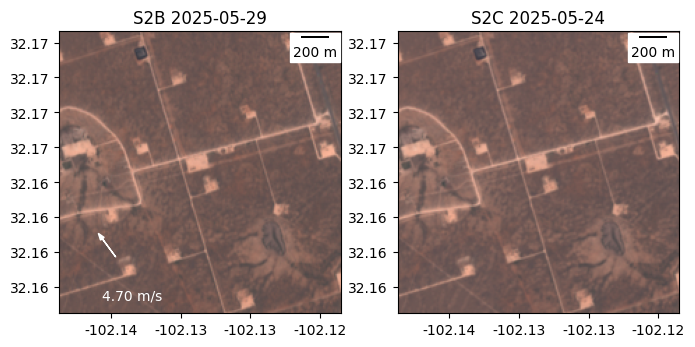

In [6]:
from georeader import plot
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
rgb = (target.image.isel({"band": [3, 2, 1]}) / 4_500).clip(0, 1)
rgb_bg = (background.image.isel({"band": [3, 2, 1]}) / 4_500).clip(0, 1)

plot.show(rgb, ax=ax[0], title=title, add_scalebar=True)
wind.add_wind_to_plot([target.wind_u, target.wind_v], ax=ax[0])
plot.show(rgb_bg, ax=ax[1], title=title_bg, add_scalebar=True)

## Compute MBMP retrieval

This is the main physics-based product in the workflow. Following [Irakullis‑Loitxate et al., 2022](https://doi.org/10.1021/acs.est.1c04873), it compares the current scene with a similar cloud-free background scene in the methane-sensitive SWIR bands to estimate atmospheric transmittance; lower MBMP values indicate a stronger methane signal, as discussed by [(Gorroño et al., 2023)](https://amt.copernicus.org/articles/16/89/2023/).

It matters because this retrieval is the core evidence of methane in multispectral imagery. In the MARS workflow, analysts validate AI detections against the physics-based MBMP retrieval and other auxiliary views to distinguish real plumes from artifacts before any notification is made.

/home/gonzalo/mambaforge/envs/marss2lpy312/lib/python3.12/site-packages/satalign/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


<Axes: >

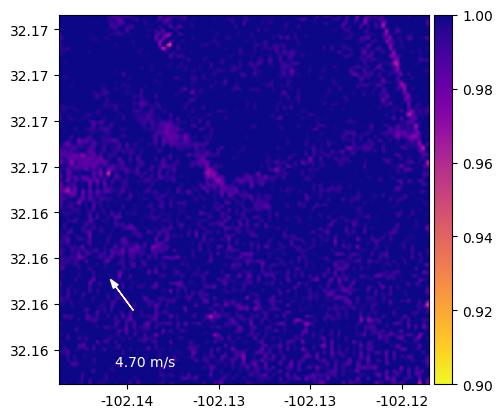

In [7]:
from marss2l.mars_sentinel2 import mixing_ratio_methane

b11_index = selector.band_index(target, "B11")
b12_index = selector.band_index(target, "B12")


if not offshore:
    mbmp = mixing_ratio_methane.ratio_IL(
        target.image, background.image,
        b11_index=b11_index, b12_index=b12_index,
        fill_value_ratio_il=1, 
        validmask=selector.validmask(target), 
        corregister=True,
    )
else:
    mbmp = mixing_ratio_methane.ratio_bands(
        target.image,
        numerator_index=b12_index,
        denominator_index=b11_index,
        validmask=selector.validmask(target), 
        fill_value_default=1,
    )

ax = plot.show(mbmp, vmin=0.9, vmax=1, 
               cmap="plasma_r", 
               add_colorbar_next_to=True)
wind.add_wind_to_plot([target.wind_u, target.wind_v], ax=ax)

## Run inference with the MARS-S2L model

At this stage the notebook has assembled the core inputs described in the paper: current imagery, reference imagery, cloud validity, and wind. The model turns those into a plume probability map.

In [8]:
from marss2l.mars_sentinel2 import plume_detection_model

model_name = "CH4Net" if offshore else "MARS-S2L"
model = plume_detection_model.load_model(model_name=model_name, logger=logger)

In [9]:
from marss2l.loaders import BANDS_S2_IN_L8
from marss2l.mars_sentinel2.s2lutils import bands_in_l89, get_channels_to_pred
channels_input = bands_in_l89(BANDS_S2_IN_L8) if islandsat else BANDS_S2_IN_L8
channels_input

['B02', 'B03', 'B04', 'B08', 'B11', 'B12']

In [10]:
from georeader import read
from rasterio.enums import Resampling

image_predict = get_channels_to_pred(target.image, channels=target.band_names, channels_model=channels_input)
image_predict_bg = get_channels_to_pred(background.image, channels=background.band_names, channels_model=channels_input)

if islandsat:
    # Interpolate to 10 m
    image_predict = read.resize(image_predict, resolution_dst=(10, 10))
    image_predict_bg = read.read_reproject_like(image_predict_bg, image_predict)
    validmask_predict = read.read_reproject_like(selector.validmask(target), 
                                                 image_predict, resampling=Resampling.nearest)
else:
    validmask_predict = selector.validmask(target)

binary_mask, scene_score, is_plume, continuous_pred = model.predict(
    image_predict=image_predict,
    background_image=image_predict_bg,
    validmask=validmask_predict,
    wind_vector=[target.wind_u, target.wind_v],
)

if islandsat:
    # Interpolate back to 30 m
    binary_mask = read.read_reproject_like(binary_mask, target.image, resampling=Resampling.nearest)
    continuous_pred = read.read_reproject_like(continuous_pred, target.image, resampling=Resampling.bilinear)

logger.info(f"Model score for image {title} is {scene_score:.4f}")

2026-06-16 13:17:36,097 - marss2l.utils - INFO - Model score for image S2B 2025-05-29 is 0.9994


<Axes: title={'center': 'Pixel prob.'}>

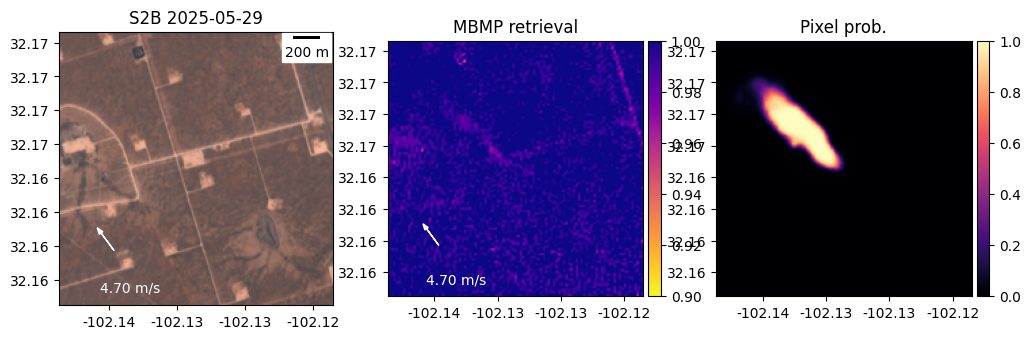

In [11]:
fig, ax = plt.subplots(1,3, figsize=(12, 4))
plot.show(rgb,ax=ax[0],title=title, add_scalebar=True)
wind.add_wind_to_plot([target.wind_u, target.wind_v], ax=ax[0])
plot.show(mbmp, vmin=0.9, vmax=1, cmap="plasma_r", add_colorbar_next_to=True, ax=ax[1], title="MBMP retrieval")
wind.add_wind_to_plot([target.wind_u, target.wind_v], ax=ax[1])
plot.show(continuous_pred, vmin=0, vmax=1, cmap="magma", add_colorbar_next_to=True, ax=ax[2], title="Pixel prob.")

## Compute the methane concentration image $\Delta\text{XCH}_4$ and the fluxrate

After detection, the next step is quantification. This combines the retrieval with the predicted plume mask to estimate methane enhancement and an approximate emission rate.

Fluxrate of image S2B 2025-05-29: 2533.46 ± 1266.82 t/h


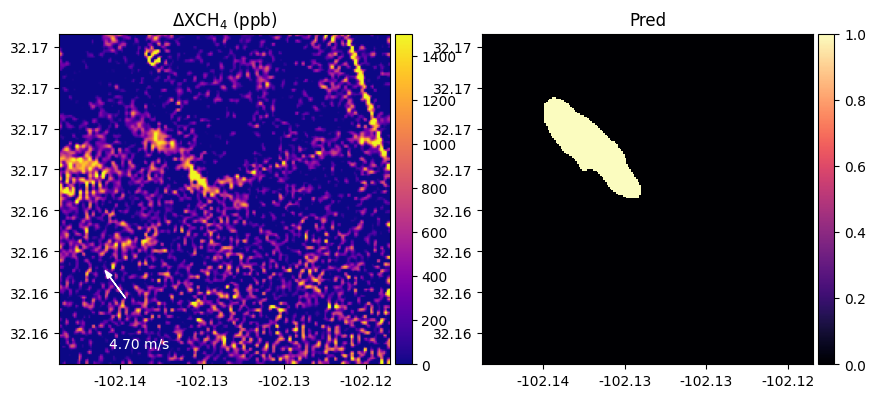

In [12]:
from marss2l.mars_sentinel2 import transmittance_to_ch4, quantification
import math

# Recompute MBMP excluding the plume from the normalization
if not offshore:
    mbmp = mixing_ratio_methane.ratio_IL(
        target.image, background.image,
        b11_index=b11_index, b12_index=b12_index,
        fill_value_ratio_il=1, validmask=selector.validmask(target),
        plumemaskbool=binary_mask.astype(bool), corregister=True,
    )
else:
    mbmp = mixing_ratio_methane.ratio_bands(
        target.image,
        numerator_index=b12_index,
        denominator_index=b11_index,
        validmask=selector.validmask(target),
        plumemaskbool=binary_mask.astype(bool),
        fill_value_default=1,
    )

ch42tr = transmittance_to_ch4.TransmittanceCH4InterpolationFromDict()
ch4 = ch42tr.deltach4_from_ratio_transmittance(
    satellite=target.satellite, sza=target.sza, vza=target.vza, ratio_il=mbmp
)

fig, ax = plt.subplots(1, 2, figsize=(10, 4.5))
plot.show(ch4, vmin=0, vmax=1_500, cmap="plasma", add_colorbar_next_to=True, title=r"$\Delta$XCH$_4$ (ppb)", ax=ax[0])
wind.add_wind_to_plot([target.wind_u, target.wind_v], ax=ax[0])

if is_plume:
    qoutput = quantification.obtain_flux_rate(ch4, binary_mask, 
                                              wind_speed=target.wind_speed(), 
                                              return_std=True)
    plot.show(binary_mask, vmin=0, vmax=1, cmap="magma", 
              add_colorbar_next_to=True, ax=ax[1], 
              title="Pred", interpolation="nearest")
    print(f"Fluxrate of image {title}: {qoutput['Q']/1_000:.2f} ± {qoutput['sigma_Q']/1_000:.2f} t/h")

## Licence
The `marss2l` package is published under a [GNU Lesser GPL v3 licence](https://www.gnu.org/licenses/lgpl-3.0.en.html)

The *MARS-S2L* database and all pre-trained models are released under a [Creative Commons non-commercial share-alike licence](https://creativecommons.org/licenses/by-nc-sa/4.0/legalcode.txt). For using the models and data in comercial pipelines written consent by UNEP IMEO must be provided.

`marss2l` tutorials and notebooks are released under a [Creative Commons non-commercial share-alike licence](https://creativecommons.org/licenses/by-nc-sa/4.0/legalcode.txt).

If you find this work useful please cite:

```bibtex
@article{mateogarcia_2026,
    title = {Artificial intelligence for methane detection: from continuous monitoring to verified mitigation},
    author = {Mateo-Garcia, Gonzalo and Allen, Anna and Irakulis-Loitxate, Itziar and Montesino-San Martin, Manuel and Watine, Marc and Randles, Cynthia and Mokalled, Tharwat and Raunak, Alma and Castañeda-Martinez, Carol and Jonhson, Juan Enmmanuel and Gorroño, Javier and Requeima, James and Cifarelli, Claudio and Guanter, Luis and Turner, Richard E. and Caltagirone, Manfredi},
    url = {http://arxiv.org/abs/2511.21777},
    doi = {10.48550/arXiv.2511.21777},
    month = nov,
    year = {2025}
}
```